In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

https://stackoverflow.com/questions/78186798/roots-of-complex-function-including-square-roots-and-exponentials

In [2]:
def k_xy_eq(kxy, k0, eps_1, eps_2, d):
    # exponential term
    exp = np.exp(2j*np.sqrt(eps_2*k0**2 - kxy**2) * d)
    # numerator of second term
    num = (np.sqrt(eps_2*k0**2 - kxy**2) + eps_2 * np.sqrt(k0**2 - kxy**2)) * (eps_2 * np.sqrt(eps_1 * k0**2 - kxy**2) + eps_1 * np.sqrt(eps_2 * k0**2 - kxy**2))
    #denominator of second term
    denom = (np.sqrt(eps_2*k0**2 - kxy**2) - eps_2 * np.sqrt(k0**2 - kxy**2)) * (eps_2 * np.sqrt(eps_1 * k0**2 - kxy**2) - eps_1 * np.sqrt(eps_2 * k0**2 - kxy**2))
    return exp * num / denom

In [3]:
k0s = np.array([7459927, 8165527, 9574340, 9695577])
eps_1 = 1.45**2
eps_2s = np.array([-26.69+1.31j, -20.88+1.16j, -12.76+1.13j, -12.22+1.14j])
d = 1e-9
initial_guess = 7603702-6832j

In [4]:
def factory(k0, eps_1, eps_2, d):
    def wrapped(x):
        kxy = x[0] + 1j * x[1]
        value = k_xy_eq(kxy, k0, eps_1, eps_2, d)
        return np.sqrt(np.real(value) ** 2 + np.imag(value) ** 2)
    return wrapped

In [5]:
p = (k0s[0], eps_1, eps_2s[0], d)

In [6]:
model = factory(*p)

In [7]:
model([0, 0])

1.0218753585550575

In [8]:
optimize.minimize(model, [0, 0])

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.0218753585550575
        x: [ 0.000e+00  0.000e+00]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 3
     njev: 1

In [9]:
x = np.linspace(-10000, 10000, 200)
y = np.linspace(-10000, 10000, 200)
X, Y = np.meshgrid(x, y)

In [10]:
Z = model([X, Y])

In [11]:
Z.min(), Z.max()

(0.9229669952489423, 1.1304751687988037)

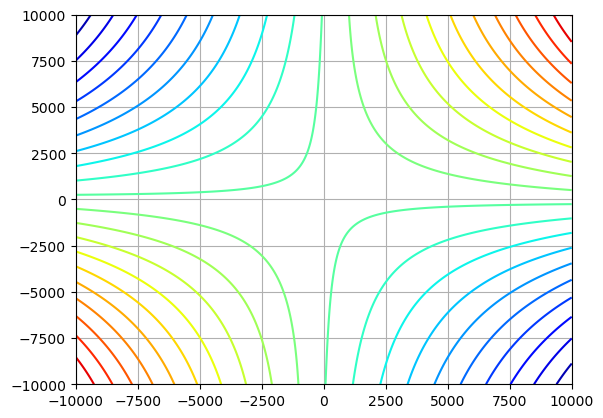

In [12]:
fig, axe = plt.subplots()
axe.contour(X, Y, Z, 20, cmap="jet")
axe.grid()